# 02 — Clasificación LLM y perfilado de usuarios — Exploit.in

Clasifica ~5.000 posts de las secciones de interés para threat intelligence  
y construye perfiles de los usuarios más activos.

**Modelo**: `qwen2.5:14b`  
**Categorías de clasificación**:

| Categoría | Descripción |
|---|---|
| `hacking` | Intrusión, vulnerabilidades, exploits, pentesting |
| `carding` | Fraude con tarjetas, dumps, CVV, sistemas de pago |
| `malware` | Troyanos, bots, crypters, exploits, ransomware |
| `spam` | Redes de spam, mailing masivo, scrapers, bases de datos |
| `marketplace` | Compraventa de servicios/credenciales/accesos |
| `programming` | Código, scripts, desarrollo, automatización |
| `community` | Discusión técnica general, preguntas, debate |
| `unknown` | No clasificable |

Produce:
- `data/processed/exploitin_sample_classified.parquet`
- `data/processed/exploitin_user_profiles.json`

## 0. Setup

In [5]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ollama
from pathlib import Path
from tqdm.auto import tqdm
from IPython.display import display

PROCESSED   = Path('../data/processed')
MODEL       = 'qwen2.5:14b'
SAMPLE_OUT  = PROCESSED / 'exploitin_sample_classified.parquet'
PROFILES_OUT = PROCESSED / 'exploitin_user_profiles.json'
CHECKPOINT  = PROCESSED / 'exploitin_classify_checkpoint.parquet'

CATEGORIES = ['hacking', 'carding', 'malware', 'spam', 'marketplace', 'programming', 'community', 'unknown']

# Cargar tablas base
posts   = pd.read_parquet(PROCESSED / 'posts.parquet')
topics  = pd.read_parquet(PROCESSED / 'topics.parquet')
forums  = pd.read_parquet(PROCESSED / 'forums.parquet')
members = pd.read_parquet(PROCESSED / 'members.parquet')

forum_name_map  = dict(zip(forums['id'], forums['name']))
topic_forum_map = dict(zip(topics['tid'], topics['forum_id']))
posts = posts.copy()
posts['forum_id']   = posts['topic_id'].map(topic_forum_map)
posts['forum_name'] = posts['forum_id'].map(forum_name_map)

print(f'Setup OK  |  Modelo: {MODEL}')

Setup OK  |  Modelo: qwen2.5:14b


## 1. Selección de muestra

~5.000 posts de secciones relevantes para threat intelligence,  
con sampling proporcional al peso de cada sección.

In [6]:
# Secciones de interés y cuota de sampling
SECTION_QUOTAS = {
    'Безопасность и взлом':         800,
    'Деньги':                        600,
    'Покупка/Продажа/Обмен/Работа':  900,
    'Вирусология':                   None,  # todos (~597)
    'Программирование':              400,
    '1st Access Level':              800,
    'Black List':                    None,  # todos (~492)
    'Криптография и приватность':    300,
    'Спам, рассылки':                400,
}

# Posts limpios: contenido > 60 chars
posts_clean = posts[
    posts['content'].str.len() > 60
].copy()

# Renombrar author_name → username para coherencia con otros módulos
posts_clean = posts_clean.rename(columns={'author_name': 'username'})

# Construir muestra
parts = []
for section, quota in SECTION_QUOTAS.items():
    sec_posts = posts_clean[posts_clean['forum_name'] == section]
    if quota is None or len(sec_posts) <= quota:
        parts.append(sec_posts)
    else:
        parts.append(sec_posts.sample(quota, random_state=42))

sample = pd.concat(parts, ignore_index=True)
sample['category'] = None  # se rellenará en la clasificación

print('Muestra por sección:')
for sec, grp in sample.groupby('forum_name', sort=False):
    print(f'  {sec:40s} {len(grp):5,} posts  ({grp["username"].nunique()} autores únicos)')
print(f'\nTotal muestra : {len(sample):,} posts')
print(f'Autores únicos: {sample["username"].nunique():,}')

Muestra por sección:
  Безопасность и взлом                       800 posts  (331 autores únicos)
  Деньги                                     600 posts  (244 autores únicos)
  Покупка/Продажа/Обмен/Работа               900 posts  (478 autores únicos)
  Вирусология                                597 posts  (195 autores únicos)
  Программирование                           400 posts  (171 autores únicos)
  1st Access Level                           800 posts  (165 autores únicos)
  Black List                                 492 posts  (150 autores únicos)
  Криптография и приватность                 300 posts  (131 autores únicos)
  Спам, рассылки                             400 posts  (150 autores únicos)

Total muestra : 5,289 posts
Autores únicos: 1,081


## 2. Clasificación LLM

Cada post se clasifica con una sola llamada a `qwen2.5:14b`.  
Checkpoint cada 100 posts para poder reanudar si se interrumpe.

In [7]:
SYSTEM_CLASSIFY = """You are a threat intelligence analyst classifying posts from a Russian underground hacking forum (Exploit.in, 2005-2008).

Classify each post into EXACTLY ONE category:
- hacking     : network intrusion, vulnerability exploitation, web hacking, password cracking, pentesting techniques
- carding     : credit card fraud, dumps, CVV, PayPal/e-money fraud, banking fraud
- malware     : trojans, bots, crypters, keyloggers, ransomware, virus development or sharing
- spam        : bulk email, spam services, scrapers, mailing databases, SMS spam
- marketplace : buying/selling/exchanging credentials, shells, ICQ numbers, services, accounts (general trade)
- programming : code snippets, scripts, programming questions, development tools, automation
- community   : general technical discussion, forum questions, off-topic, greetings, opinion, debates
- unknown     : cannot determine from the text

Reply with ONLY the category name, nothing else."""


def classify_post(content: str) -> str:
    try:
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_CLASSIFY},
                {'role': 'user',   'content': content[:600]},
            ],
            options={'temperature': 0.0, 'num_predict': 10},
        )
        raw = resp.message.content.strip().lower()
        # Extraer primera palabra que sea una categoría válida
        for word in re.split(r'[\s,;.\n]+', raw):
            if word in CATEGORIES:
                return word
        return 'unknown'
    except Exception:
        return 'unknown'

In [8]:
# Cargar checkpoint si existe
if CHECKPOINT.exists():
    done = pd.read_parquet(CHECKPOINT)
    done_ids = set(done['pid'])
    print(f'Checkpoint: {len(done_ids):,} posts ya clasificados')
else:
    done = pd.DataFrame(columns=sample.columns)
    done_ids = set()
    print('Sin checkpoint — clasificando desde cero')

pending = sample[~sample['pid'].isin(done_ids)].copy()
print(f'Pendientes: {len(pending):,}')

BATCH_CHECKPOINT = 100
results = list(done.itertuples(index=False, name=None)) if len(done) else []
done_rows = done.to_dict('records') if len(done) else []

for i, row in enumerate(tqdm(pending.itertuples(index=False), total=len(pending), desc='Clasificando')):
    cat = classify_post(row.content)
    record = {col: getattr(row, col) for col in pending.columns}
    record['category'] = cat
    done_rows.append(record)

    if (i + 1) % BATCH_CHECKPOINT == 0:
        pd.DataFrame(done_rows).to_parquet(CHECKPOINT, index=False)

# Guardar clasificación completa
classified = pd.DataFrame(done_rows)
classified.to_parquet(SAMPLE_OUT, index=False)
CHECKPOINT.unlink(missing_ok=True)

print(f'\nClasificación completada: {len(classified):,} posts')
print(classified['category'].value_counts().to_string())

Sin checkpoint — clasificando desde cero
Pendientes: 5,289


Clasificando: 100%|█████████████████████████| 5289/5289 [13:59<00:00,  6.30it/s]


Clasificación completada: 5,289 posts
category
community      1568
hacking         784
marketplace     775
programming     694
malware         658
spam            404
carding         291
unknown         115


## 3. Distribución de categorías

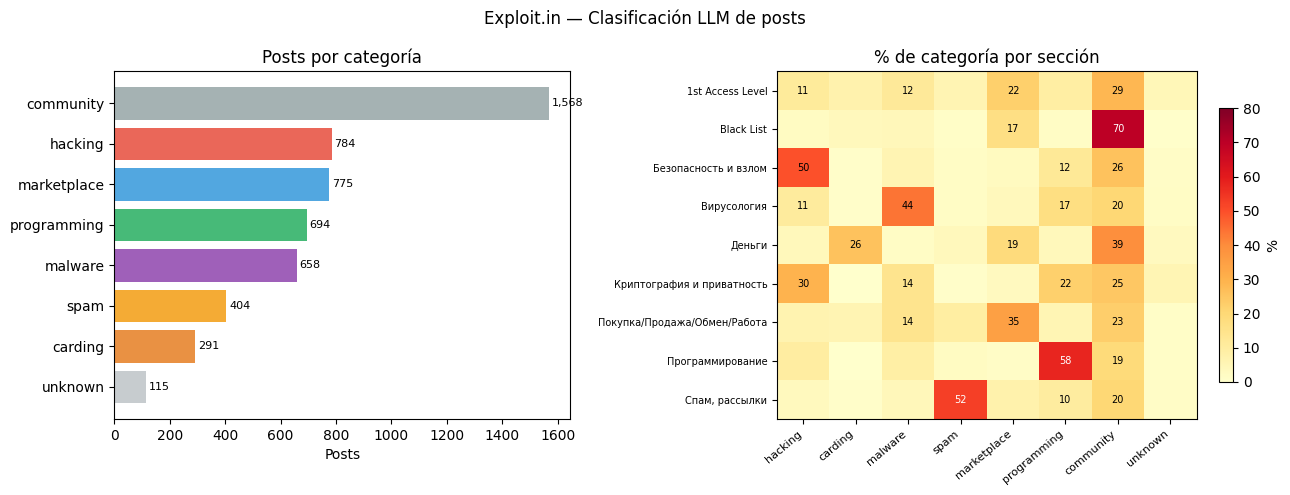


Resumen: 5,289 posts clasificados
  Sin clasificar (unknown): 115 (2.2%)


In [9]:
classified = pd.read_parquet(SAMPLE_OUT)

cat_counts = classified['category'].value_counts()

cat_colors = {
    'hacking':     '#e74c3c',
    'carding':     '#e67e22',
    'malware':     '#8e44ad',
    'spam':        '#f39c12',
    'marketplace': '#3498db',
    'programming': '#27ae60',
    'community':   '#95a5a6',
    'unknown':     '#bdc3c7',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [cat_colors.get(c, '#aaa') for c in cat_counts.index]
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1], alpha=0.85)
axes[0].set_title('Posts por categoría')
axes[0].set_xlabel('Posts')
for bar, val in zip(axes[0].patches, cat_counts.values[::-1]):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# Heatmap sección × categoría
cross = pd.crosstab(classified['forum_name'], classified['category'])
cross = cross[[c for c in CATEGORIES if c in cross.columns]]
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

im = axes[1].imshow(cross_pct.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=80)
axes[1].set_xticks(range(len(cross_pct.columns)))
axes[1].set_xticklabels(cross_pct.columns, rotation=40, ha='right', fontsize=8)
axes[1].set_yticks(range(len(cross_pct.index)))
axes[1].set_yticklabels([s[:30] for s in cross_pct.index], fontsize=7)
axes[1].set_title('% de categoría por sección')
plt.colorbar(im, ax=axes[1], fraction=0.03, label='%')

for i in range(len(cross_pct.index)):
    for j in range(len(cross_pct.columns)):
        v = cross_pct.values[i, j]
        if v > 10:
            axes[1].text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                         color='white' if v > 50 else 'black')

plt.suptitle('Exploit.in — Clasificación LLM de posts', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nResumen: {len(classified):,} posts clasificados')
print(f'  Sin clasificar (unknown): {(classified["category"]=="unknown").sum():,} ({(classified["category"]=="unknown").mean()*100:.1f}%)')

## 4. Perfilado de usuarios

Para cada usuario con ≥ 8 posts en la muestra, el LLM genera un perfil  
con su especialidad, rol en la comunidad y resumen de actividad.

In [10]:
SYSTEM_PROFILE = """You are a threat intelligence analyst profiling members of Exploit.in, a Russian underground hacking forum (2005-2008).

Given a selection of posts from a single user, return a JSON profile with these fields:
- "specialty": primary area of activity — one of: hacking, carding, malware, spam, marketplace, programming, community
- "role": their role in the ecosystem — one of: seller, buyer, teacher, developer, moderator, community_member, scammer, unknown
- "confidence": how confident you are — one of: high, medium, low
- "summary": 1-2 sentences in English describing their activity and typical behavior
- "evidence": list of 2-3 short quotes or paraphrases from their posts that support the profile

Return ONLY valid JSON, no explanation."""


def profile_user(username: str, user_posts: list[str]) -> dict:
    sample_posts = user_posts[:15]  # máximo 15 posts por usuario
    posts_text = '\n---\n'.join(p[:300] for p in sample_posts)
    prompt = f'Username: {username}\n\nPosts:\n{posts_text}'
    try:
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROFILE},
                {'role': 'user',   'content': prompt},
            ],
            options={'temperature': 0.1, 'num_predict': 300},
        )
        raw = resp.message.content.strip()
        m = re.search(r'\{.*\}', raw, re.DOTALL)
        return json.loads(m.group()) if m else {'specialty': 'unknown', 'role': 'unknown',
                                                 'confidence': 'low', 'summary': '', 'evidence': []}
    except Exception:
        return {'specialty': 'unknown', 'role': 'unknown',
                'confidence': 'low', 'summary': '', 'evidence': []}

In [11]:
MIN_POSTS = 8

# Usuarios con suficientes posts en la muestra
user_post_counts = classified.groupby('username').size()
active_users = user_post_counts[user_post_counts >= MIN_POSTS].index.tolist()
print(f'Usuarios con ≥{MIN_POSTS} posts en la muestra: {len(active_users)}')

# Cargar perfiles ya calculados
profiles_path = PROCESSED / 'exploitin_user_profiles.json'
if profiles_path.exists():
    with open(profiles_path) as f:
        profiles = json.load(f)
    print(f'Perfiles ya calculados: {len(profiles)}')
else:
    profiles = {}

pending_users = [u for u in active_users if u not in profiles]
print(f'Pendientes: {len(pending_users)}')

for user in tqdm(pending_users, desc='Perfilando usuarios'):
    user_posts = classified[classified['username'] == user]['content'].tolist()
    profiles[user] = profile_user(user, user_posts)
    # Checkpoint cada 20 usuarios
    if len(profiles) % 20 == 0:
        with open(profiles_path, 'w', encoding='utf-8') as f:
            json.dump(profiles, f, ensure_ascii=False, indent=2)

# Guardar final
with open(profiles_path, 'w', encoding='utf-8') as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2)

print(f'\nPerfiles guardados: {len(profiles)}')

Usuarios con ≥8 posts en la muestra: 156
Pendientes: 156


Perfilando usuarios: 100%|████████████████████| 156/156 [15:11<00:00,  5.84s/it]


Perfiles guardados: 156


## 5. Análisis de perfiles

=== DISTRIBUCIÓN DE ESPECIALIDADES ===
specialty
hacking        46
malware        32
programming    24
carding        14
spam           12
unknown        11
community      11
scamming        3
marketplace     3

=== DISTRIBUCIÓN DE ROLES ===
role
community_member    51
seller              32
teacher             24
developer           19
unknown             11
moderator            8
buyer                7
scammer              3
learner              1


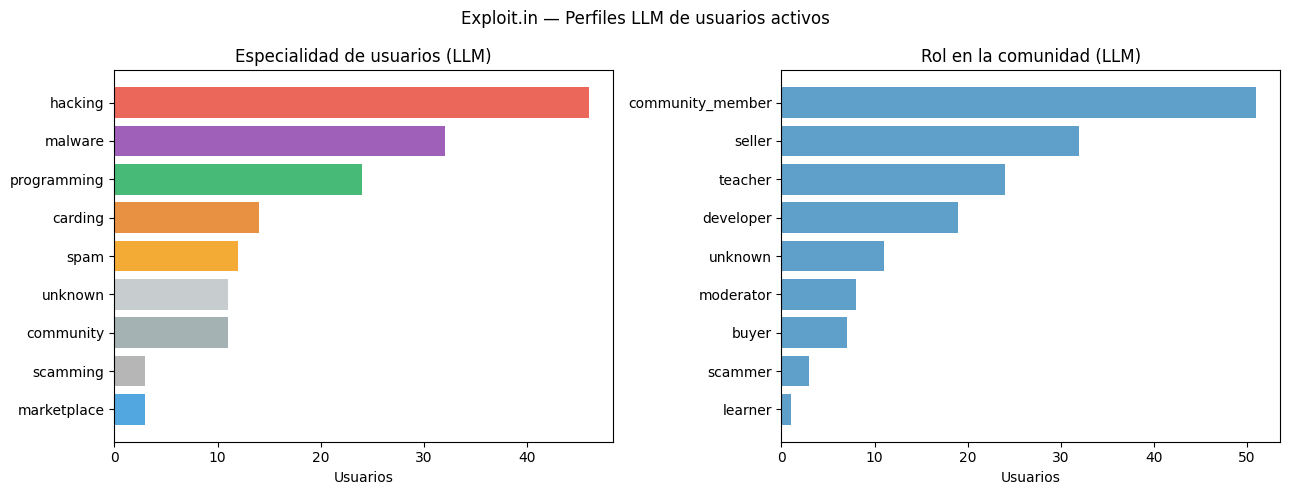

In [12]:
with open(PROFILES_OUT) as f:
    profiles = json.load(f)

profiles_df = pd.DataFrame([
    {
        'username':   u,
        'specialty':  p.get('specialty', 'unknown'),
        'role':       p.get('role', 'unknown'),
        'confidence': p.get('confidence', 'low'),
        'summary':    p.get('summary', ''),
        'posts_sample': user_post_counts.get(u, 0),
    }
    for u, p in profiles.items()
])

print('=== DISTRIBUCIÓN DE ESPECIALIDADES ===')
print(profiles_df['specialty'].value_counts().to_string())
print('\n=== DISTRIBUCIÓN DE ROLES ===')
print(profiles_df['role'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

spec_counts = profiles_df['specialty'].value_counts()
colors_spec = [cat_colors.get(c, '#aaa') for c in spec_counts.index]
axes[0].barh(spec_counts.index[::-1], spec_counts.values[::-1], color=colors_spec[::-1], alpha=0.85)
axes[0].set_title('Especialidad de usuarios (LLM)')
axes[0].set_xlabel('Usuarios')

role_counts = profiles_df['role'].value_counts()
axes[1].barh(role_counts.index[::-1], role_counts.values[::-1], color='#2980b9', alpha=0.75)
axes[1].set_title('Rol en la comunidad (LLM)')
axes[1].set_xlabel('Usuarios')

plt.suptitle('Exploit.in — Perfiles LLM de usuarios activos', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# Cruce specialty × rol
cross_roles = pd.crosstab(profiles_df['specialty'], profiles_df['role'])
print('Especialidad × Rol:')
display(cross_roles)

# Muestra de perfiles por especialidad
for specialty in ['hacking', 'carding', 'malware', 'marketplace']:
    sub = profiles_df[profiles_df['specialty'] == specialty].sort_values('posts_sample', ascending=False).head(3)
    if len(sub) == 0:
        continue
    print(f'\n=== {specialty.upper()} — top 3 usuarios ===')
    for _, row in sub.iterrows():
        print(f'  {row["username"]:20s} [{row["role"]:18s} / conf:{row["confidence"]}]  {row["posts_sample"]} posts')
        print(f'    {row["summary"][:110]}')

Especialidad × Rol:


role,buyer,community_member,developer,learner,moderator,scammer,seller,teacher,unknown
specialty,,,,,,,,,
carding,4,3,0,0,1,0,4,2,0
community,0,2,1,0,7,0,0,1,0
hacking,0,27,2,0,0,0,4,13,0
malware,0,3,12,1,0,0,14,2,0
marketplace,1,0,0,0,0,0,2,0,0
programming,0,14,4,0,0,0,0,6,0
scamming,0,0,0,0,0,3,0,0,0
spam,2,2,0,0,0,0,8,0,0
unknown,0,0,0,0,0,0,0,0,11



=== HACKING — top 3 usuarios ===
  toha                 [teacher            / conf:high]  156 posts
    toha is an active member who frequently shares information on vulnerabilities, exploits, and hacking technique
  prosto               [teacher            / conf:high]  149 posts
    Prosto is an active member who frequently shares hacking techniques and exploits, often teaching others how to
  gwkuo                [community_member   / conf:high]  90 posts
    gwkuo is an active community member who frequently discusses technical aspects of hacking, including DDoS atta

=== CARDING — top 3 usuarios ===
  Ex0rсi&#036;t        [teacher            / conf:high]  75 posts
    Ex0rсi&#036;t is an experienced carder who frequently advises others on the intricacies of carding, including 
  p_end                [community_member   / conf:high]  25 posts
    p_end is an active member of the carding community who shares information about security breaches, carder arre
  tear                 [b

In [14]:
# Muestra de posts por categoría
print('=== MUESTRA DE POSTS CLASIFICADOS ===')
for cat in ['hacking', 'carding', 'malware', 'marketplace']:
    sub = classified[classified['category'] == cat].sample(min(2, (classified['category']==cat).sum()), random_state=42)
    print(f'\n--- {cat.upper()} ---')
    for _, row in sub.iterrows():
        date_str = row['post_date'].strftime('%Y-%m-%d') if pd.notna(row.get('post_date')) else 'N/A'
        print(f'[{row["username"]} · {row["forum_name"]} · {date_str}]')
        print(row['content'][:300])
        print()

=== MUESTRA DE POSTS CLASIFICADOS ===

--- HACKING ---
[WindEX · 1st Access Level · 2007-04-05]
Цитата(Nucleus @ Apr 4 2007, 18:21) prosto , хорошие логи, но всё уже стырили там даже 6 были)) ..... 46818 Блин, вот зачем такие посты? Во-первых, мы и сами логи умеем читать. Во-вторых, люди просто заходят в топик и меняют пассы на все номера! Пусть хоть потрудятся логи прочитать, может тогда хоть

[Plaza · 1st Access Level · 2007-12-02]
Name: http://magra.info/index.php Values: administrator password -------------------------- Name: http://www.dpexthailand.com/admin/ Values: inter inter -------------------------- Name: http://bill.cs-resource.kiev.ua/forum/login.php Values: admin 4193212 -------------------------- Name: http://www.


--- CARDING ---
[lithuaniamafia · Деньги · 2008-01-13]
ABA (American Bankers Association) - Ассоциация американских банкиров. ABA Routing Number - Уникальное девятизначное число, стоит в нижней части чека перед номером счета (обычно обрамленное двоеточиями). 

## 6. Resumen

In [15]:
print('='*55)
print('EXPLOIT.IN — CLASIFICACIÓN LLM')
print('='*55)
print(f'Posts clasificados  : {len(classified):,}')
print(f'Usuarios perfilados : {len(profiles):,}')
print(f'Modelo              : {MODEL}')
print()
print('Top categorías:')
for cat, n in classified['category'].value_counts().items():
    print(f'  {cat:15s}: {n:5,} ({n/len(classified)*100:.1f}%)')
print()
print('Archivos generados:')
print(f'  {SAMPLE_OUT.name}')
print(f'  {PROFILES_OUT.name}')

EXPLOIT.IN — CLASIFICACIÓN LLM
Posts clasificados  : 5,289
Usuarios perfilados : 156
Modelo              : qwen2.5:14b

Top categorías:
  community      : 1,568 (29.6%)
  hacking        :   784 (14.8%)
  marketplace    :   775 (14.7%)
  programming    :   694 (13.1%)
  malware        :   658 (12.4%)
  spam           :   404 (7.6%)
  carding        :   291 (5.5%)
  unknown        :   115 (2.2%)

Archivos generados:
  exploitin_sample_classified.parquet
  exploitin_user_profiles.json
